<a href="https://colab.research.google.com/github/noor-gh06/Cybercrime-DataMining/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cybersecurity_large_synthesized_data 2.csv to cybersecurity_large_synthesized_data 2.csv


In [ ]:
import pandas as pd

df = pd.read_csv("cybersecurity_large_synthesized_data 2.csv")
df.head()

,attack_type,target_system,outcome,timestamp,attacker_ip,target_ip,data_compromised_GB,attack_duration_min,security_tools_used,user_role,location,attack_severity,industry,response_time_min,mitigation_method
0,Phishing,Cloud Service,Failure,2024-04-03 11:13:15.083419,21.166.79.4,23.20.50.78,15.31,300,Firewall,Employee,Australia,2,Energy,164,Containment
1,DDoS,Email Server,Success,2024-02-03 20:51:56.083463,187.180.150.169,34.160.58.218,65.05,242,Endpoint Detection,Admin,Brazil,10,Retail,64,Reset Credentials
2,Zero-Day Exploit,Cloud Service,Success,2024-07-19 18:40:05.083472,57.161.159.140,213.142.125.206,48.99,120,Firewall,External User,Germany,7,Finance,87,Quarantine
3,SQL Injection,Email Server,Failure,2023-12-08 00:54:17.083478,207.108.16.104,4.104.193.49,16.29,286,MFA,Employee,Russia,3,Healthcare,23,Patch
4,Zero-Day Exploit,IoT Device,Failure,2024-07-23 05:38:20.083483,98.122.15.31,57.66.53.194,87.66,4,Firewall,Contractor,UK,6,Finance,129,Containment


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   attack_type          100000 non-null  object 
 1   target_system        100000 non-null  object 
 2   outcome              100000 non-null  object 
 3   timestamp            100000 non-null  object 
 4   attacker_ip          100000 non-null  object 
 5   target_ip            100000 non-null  object 
 6   data_compromised_GB  100000 non-null  float64
 7   attack_duration_min  100000 non-null  int64  
 8   security_tools_used  100000 non-null  object 
 9   user_role            100000 non-null  object 
 10  location             100000 non-null  object 
 11  attack_severity      100000 non-null  int64  
 12  industry             100000 non-null  object 
 13  response_time_min    100000 non-null  int64  
 14  mitigation_method    100000 non-null  object 
dtypes: float64(1), int

In [ ]:
df.describe()

,data_compromised_GB,attack_duration_min,attack_severity,response_time_min
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.062586,151.070590,5.498990,90.454450
std,28.829756,86.733278,2.869718,51.905376
min,0.000000,1.000000,1.000000,1.000000
25%,25.170000,76.000000,3.000000,46.000000
50%,50.060000,151.000000,5.000000,90.000000
75%,74.970000,226.000000,8.000000,135.000000
max,100.000000,300.000000,10.000000,180.000000


In [ ]:
df.describe().loc[['min', '25%', '50%', '75%', 'max']]

,data_compromised_GB,attack_duration_min,attack_severity,response_time_min
min,0.00,1.0,1.0,1.0
25%,25.17,76.0,3.0,46.0
50%,50.06,151.0,5.0,90.0
75%,74.97,226.0,8.0,135.0
max,100.00,300.0,10.0,180.0


In [ ]:
corr = df.select_dtypes(include='number').corr()
corr

,data_compromised_GB,attack_duration_min,attack_severity,response_time_min
data_compromised_GB,1.000000,-0.000763,-0.001609,-0.001225
attack_duration_min,-0.000763,1.000000,-0.004516,-0.001168
attack_severity,-0.001609,-0.004516,1.000000,-0.004034
response_time_min,-0.001225,-0.001168,-0.004034,1.000000


In [5]:
from google.colab import files
uploaded = files.upload()

Saving Cyber Crimes Dataset.csv to Cyber Crimes Dataset (1).csv


In [8]:
### Dataset Overview
#The dataset consists of 100,000 rows and 15 columns, indicating a large dataset with multiple features available for analysis.

import pandas as pd
df = pd.read_csv("Cyber Crimes Dataset.csv")
df.head()
df.shape

(100000, 15)

In [9]:
#تحديد الأعمدة الرقمية
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

Numeric columns: ['data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min']


In [15]:
#Missing Values Analysis
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
}).sort_values("missing_count", ascending=False)

print(missing_summary)

                     missing_count  missing_percent
attack_type                      0              0.0
target_system                    0              0.0
outcome                          0              0.0
timestamp                        0              0.0
attacker_ip                      0              0.0
target_ip                        0              0.0
data_compromised_GB              0              0.0
attack_duration_min              0              0.0
security_tools_used              0              0.0
user_role                        0              0.0
location                         0              0.0
attack_severity                  0              0.0
industry                         0              0.0
response_time_min                0              0.0
mitigation_method                0              0.0


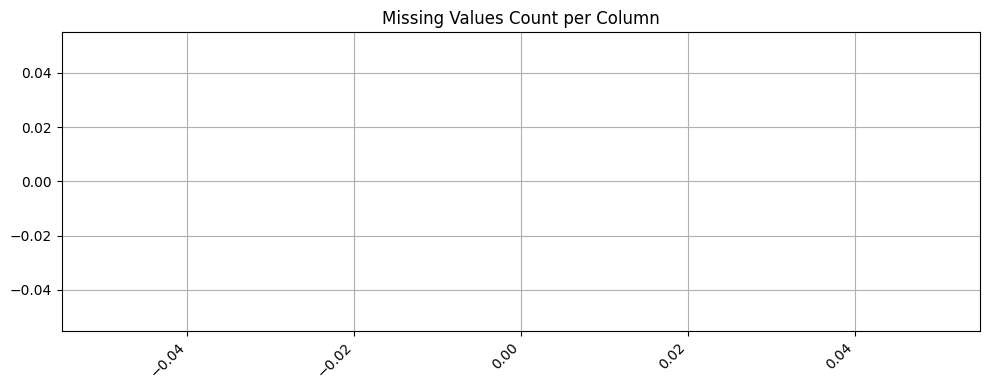

No missing values found (0 missing).


In [16]:
#Missing Values Analysis
miss_only = missing_summary[missing_summary["missing_count"] > 0]

plt.figure(figsize=(10,4))
plt.bar(miss_only.index.astype(str), miss_only["missing_count"])
plt.xticks(rotation=45, ha="right")
plt.title("Missing Values Count per Column")
plt.tight_layout()
plt.show()

if miss_only.empty:
    print("No missing values found (0 missing).")
    ### Missing Values Analysis

#The missing value analysis shows that all columns contain 0 missing values.
#The dataset is complete and does not require any missing value imputation or row removal.

#This ensures that no information is lost during preprocessing and simplifies the data preparation phase.

In [18]:
#Skewness
skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness values:")
print(skew_vals)

Skewness values:
response_time_min      0.003005
attack_severity        0.001954
data_compromised_GB   -0.001700
attack_duration_min   -0.003909
dtype: float64


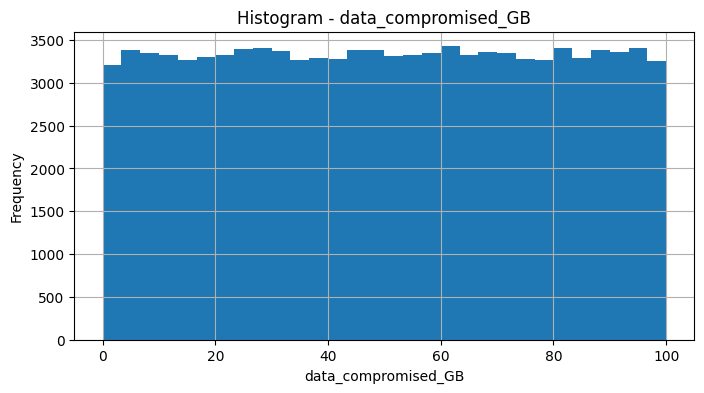

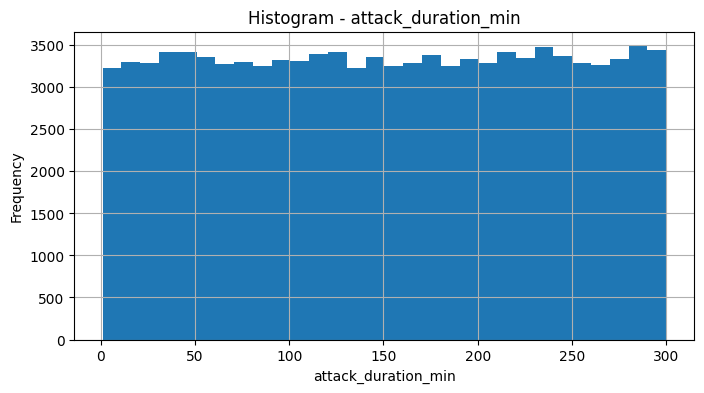

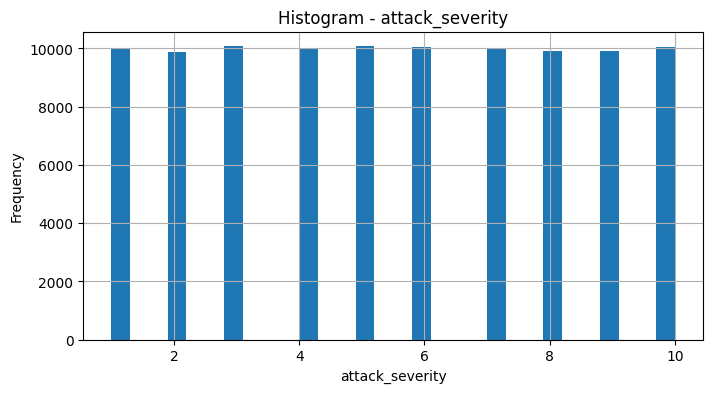

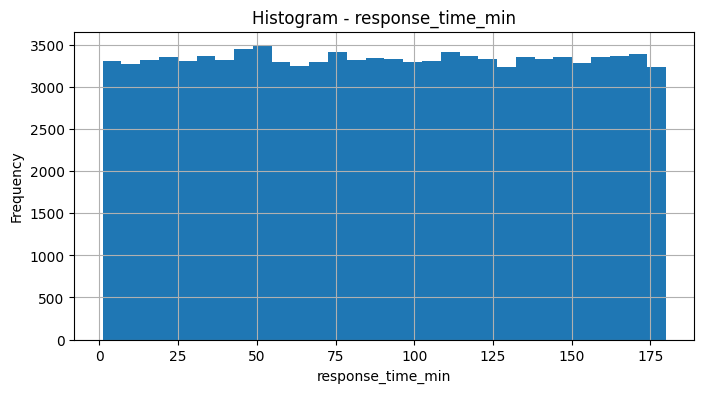

In [19]:
#Histograms
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

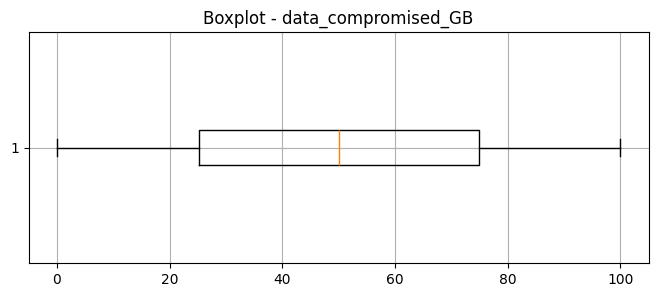

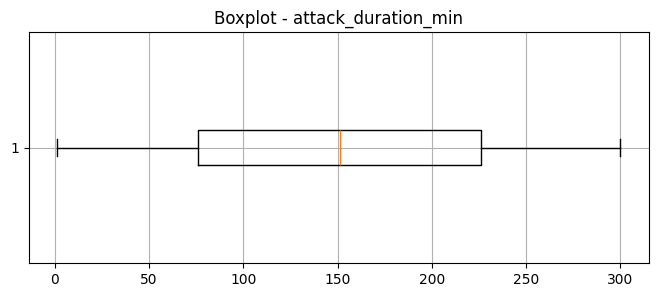

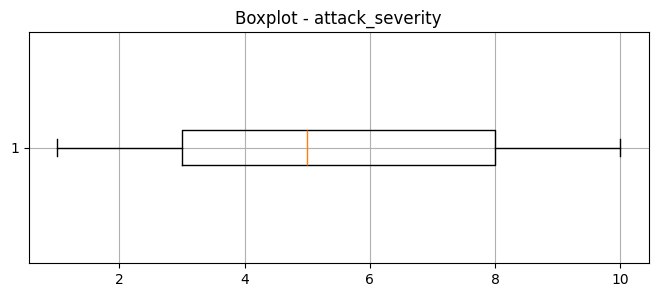

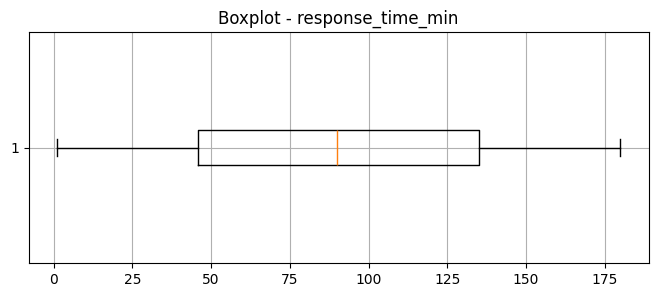

                column  outlier_count
0  data_compromised_GB              0
1  attack_duration_min              0
2      attack_severity              0
3    response_time_min              0


In [21]:
#Boxplots + Outliers (IQR Method)
def iqr_outliers_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers

outlier_report = []

for col in numeric_cols:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot - {col}")
    plt.show()

    outliers = iqr_outliers_count(df[col])
    outlier_report.append([col, outliers])

outlier_df = pd.DataFrame(outlier_report, columns=["column", "outlier_count"])
print(outlier_df.sort_values("outlier_count", ascending=False))

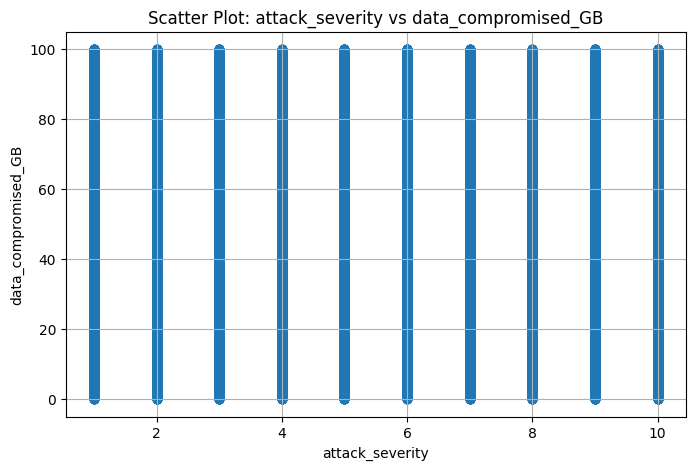

In [22]:
#Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(df["attack_severity"], df["data_compromised_GB"], alpha=0.6)
plt.title("Scatter Plot: attack_severity vs data_compromised_GB")
plt.xlabel("attack_severity")
plt.ylabel("data_compromised_GB")
plt.show()

In [26]:
#Range Check (عشان تبررين Normalization)
range_data = []

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    range_val = max_val - min_val
    range_data.append([col, min_val, max_val, range_val])

range_df = pd.DataFrame(range_data, columns=["column", "min", "max", "range"])
print(range_df.sort_values("range", ascending=False))

                column  min    max  range
1  attack_duration_min  1.0  300.0  299.0
3    response_time_min  1.0  180.0  179.0
0  data_compromised_GB  0.0  100.0  100.0
2      attack_severity  1.0   10.0    9.0


تم تحديد القيم الشاذة باستخدام مخطط Boxplot وطريقة IQR الإحصائية.
تم اعتبار أي قيمة تقع خارج المجال المحدد بـ Q1 − 1.5×IQR و Q3 + 1.5×IQR قيمة شاذة.

وقد أظهرت النتائج وجود قيم متطرفة خاصة في متغير data_compromised_GB مما يشير إلى احتمال وجود ضوضاء في البيانات.

Outliers were identified using boxplots and the IQR method.
Values falling outside the range defined by Q1 − 1.5×IQR and Q3 + 1.5×IQR were considered outliers.

The presence of extreme values, particularly in data_compromised_GB and attack_duration_min, indicates potential noise in the dataset.